# 02 — GLO Databricks EDA

**Project:** GlacierGuard AI  
**Dataset:** Glacial Lake Observatory (GLO) — Nepal & Transboundary Catchments (2017–2024) v1.02  
**Source:** Rawlins et al. (2025) — Zenodo: https://doi.org/10.5281/zenodo.17802333  
**Licence:** CC BY 4.0  

---

This notebook performs the **first proper exploratory data analysis** of the GLO **annual** glacial-lake datasets using Databricks/Spark.  
It uses the annual time-series GeoPackages (one row per lake per year) rather than the dissolved unique-lake files.

### Annual Files Used
| File | Sensor | Rows | Unique Lakes | Years |
|---|---|---|---|---|
| `S1_20172024_NTB_GLOID_v1.02.gpkg` | Sentinel-1 (SAR) | 18,129 | 2,966 | 2017–2024 |
| `S2_20172024_NTB_GLOID_v1.02.gpkg` | Sentinel-2 (Optical) | 22,294 | 4,150 | 2017–2024 |

### Key Columns (Annual Files)
| Column | Type | Description |
|---|---|---|
| `GLO_ID` | Text | Unique lake identifier (`GLO_lon_lat`) |
| `AREA_YEAR` | Int | Year of observation (2017–2024) |
| `AREA` | Float | Lake surface area (km²) |
| `AREA_UNCERTAINTY` | Float | Estimated uncertainty in lake area (km²) |
| `PERIMETER` | Float | Lake perimeter (km) |
| `CONNECTIVITY` | Text | Glacier-fed / Non Glacier-fed |
| `ELEVATION_MEAN/MIN/MEDIAN` | Float | Lake-surface elevation (m, ALOS AW3D30) |
| `START_DATE` / `END_DATE` | Date | Observation period start and end |
| `TS_OUTLIER` | Text | Boolean flag — temporal outlier in time series |
| `COUNTRY` | Text | Nepal / China / India |
| `BASIN` | Text | Hydrological basin |
| `GTNG_REGION_O2` | Text | GTN-G region code |

### Rules
- **Read-only**: Raw GeoPackage files are never modified.
- **No ML**: No feature engineering or model training in this notebook.
- **Reproducible**: All analysis uses Spark for scalability.

---

## 1 — Environment and Databricks Connection Verification

In [1]:
# == 1.1  Verify Spark session ==
# On a Databricks cluster, `spark` is available as a global.
# With Databricks Connect from an IDE, we build the session explicitly.

import os
os.environ.setdefault('DATABRICKS_SERVERLESS_COMPUTE_ID', 'auto')

try:
    # Already on a Databricks cluster?
    _ = spark  # noqa: F821
    print('Spark session: available (Databricks cluster)')
except NameError:
    try:
        from databricks.connect import DatabricksSession
        spark = DatabricksSession.builder.getOrCreate()
        print('Spark session: created via Databricks Connect')
    except Exception as e:
        print(f'Databricks Connect exception: {e}')
        raise

print(f'Spark version : {spark.version}')
print('Connected via : Databricks Connect (Spark Connect v2)')


Spark session: created via Databricks Connect
Spark version : 4.2.0
Connected via : Databricks Connect (Spark Connect v2)


In [2]:
# == 1.2  Databricks runtime information ==
import os

dbr_version = os.environ.get('DATABRICKS_RUNTIME_VERSION', 'N/A (not on Databricks cluster)')
print(f'Databricks Runtime Version: {dbr_version}')

# Spark configuration snapshot
for key in ['spark.databricks.clusterUsageTags.clusterName',
            'spark.databricks.clusterUsageTags.sparkVersion',
            'spark.databricks.clusterUsageTags.clusterAllTags']:
    try:
        val = spark.conf.get(key, 'N/A')
        print(f'{key}: {val}')
    except Exception:
        pass

Databricks Runtime Version: N/A (not on Databricks cluster)


In [3]:
# == 1.3  Library versions ==
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import fiona

from pyspark.sql import functions as F
from pyspark.sql import Window
from pyspark.sql.types import (
    StructType, StructField, StringType, IntegerType,
    DoubleType, TimestampType
)

print(f'GeoPandas   : {gpd.__version__}')
print(f'Pandas      : {pd.__version__}')
print(f'NumPy       : {np.__version__}')
print(f'Matplotlib  : {matplotlib.__version__}')
print(f'Fiona       : {fiona.__version__}')

GeoPandas   : 1.1.4
Pandas      : 2.2.3
NumPy       : 2.1.3
Matplotlib  : 3.10.9
Fiona       : 1.10.1


## 2 — Locate and Inspect the GLO Annual Datasets

In [4]:
# == 2.1  Locate files ==
import pathlib

# Adapt path whether running from notebooks/ or project root
GLO_DIR_candidates = [
    pathlib.Path('../raw/GLO'),        # from notebooks/
    pathlib.Path('./raw/GLO'),          # from project root
    pathlib.Path('/Workspace/raw/GLO'), # Databricks workspace path
]

GLO_DIR = None
for p in GLO_DIR_candidates:
    if p.exists():
        GLO_DIR = p.resolve()
        break

if GLO_DIR is None:
    raise FileNotFoundError(
        'Cannot locate raw/GLO directory. '
        'Ensure the raw GLO GeoPackage files are accessible.'
    )

S1_ANNUAL_PATH = GLO_DIR / 'S1_20172024_NTB_GLOID_v1.02.gpkg'
S2_ANNUAL_PATH = GLO_DIR / 'S2_20172024_NTB_GLOID_v1.02.gpkg'

print(f'GLO directory  : {GLO_DIR}')
print(f'S1 annual file : {S1_ANNUAL_PATH.name}  exists={S1_ANNUAL_PATH.exists()}  '
      f'size={S1_ANNUAL_PATH.stat().st_size / 1e6:.1f} MB')
print(f'S2 annual file : {S2_ANNUAL_PATH.name}  exists={S2_ANNUAL_PATH.exists()}  '
      f'size={S2_ANNUAL_PATH.stat().st_size / 1e6:.1f} MB')

GLO directory  : C:\Users\ASUS\Desktop\GlacierGuard-AI\raw\GLO
S1 annual file : S1_20172024_NTB_GLOID_v1.02.gpkg  exists=True  size=30.0 MB
S2 annual file : S2_20172024_NTB_GLOID_v1.02.gpkg  exists=True  size=36.3 MB


In [5]:
# == 2.2  Inspect GeoPackage layers and metadata ==
for label, path in [('S1 Annual', S1_ANNUAL_PATH), ('S2 Annual', S2_ANNUAL_PATH)]:
    layers = fiona.listlayers(str(path))
    print(f'\n{"=" * 60}')
    print(f'{label}: {path.name}')
    print(f'{"=" * 60}')
    print(f'Layers: {layers}')
    with fiona.open(str(path), layer=layers[0]) as src:
        print(f'CRS            : {src.crs}')
        print(f'Driver         : {src.driver}')
        print(f'Feature count  : {len(src):,}')
        print(f'Geometry type  : {src.schema["geometry"]}')
        print(f'Schema fields  :')
        for field_name, field_type in src.schema['properties'].items():
            print(f'  {field_name:<25} {field_type}')


S1 Annual: S1_20172024_NTB_GLOID_v1.02.gpkg
Layers: ['s1_20172024_ntb_gloid_v1.02']
CRS            : ESRI:102025
Driver         : GPKG
Feature count  : 18,129
Geometry type  : MultiPolygon
Schema fields  :
  GLO_ID                    str
  COUNTRY                   str
  BASIN                     str
  AREA_YEAR                 int32
  AREA                      float
  PERIMETER                 float
  CONNECTIVITY              str
  ELEVATION_MEAN            float
  ELEVATION_MIN             float
  ELEVATION_MEDIAN          float
  DATA_SOURCE               str
  START_DATE                date
  END_DATE                  date
  REF_MSTAT                 str
  S2_MSTAT                  int32
  LONGITUDE                 float
  LATITUDE                  float
  GTNG_REGION_O2            str
  TS_OUTLIER                str
  AREA_UNCERTAINTY          float

S2 Annual: S2_20172024_NTB_GLOID_v1.02.gpkg
Layers: ['s2_20172024_ntb_gloid_v1.02']
CRS            : ESRI:102025
Driver         : 

In [6]:
# == 2.3  Quick peek at first 3 rows (without loading full dataset into pandas) ==
for label, path in [('S1 Annual', S1_ANNUAL_PATH), ('S2 Annual', S2_ANNUAL_PATH)]:
    gdf_peek = gpd.read_file(str(path), rows=3)
    print(f'\n=== {label} — first 3 rows ===')
    display(gdf_peek.drop(columns='geometry'))


=== S1 Annual — first 3 rows ===

=== S2 Annual — first 3 rows ===


,GLO_ID,COUNTRY,BASIN,AREA_YEAR,AREA,PERIMETER,CONNECTIVITY,ELEVATION_MEAN,ELEVATION_MIN,ELEVATION_MEDIAN,DATA_SOURCE,START_DATE,END_DATE,REF_MSTAT,S2_MSTAT,LONGITUDE,LATITUDE,GTNG_REGION_O2,TS_OUTLIER,AREA_UNCERTAINTY
0,GLO_81.57702_29.89793,Nepal,Karnali,2019,0.364947,3.183147,Glacier-fed,3588.165283,3557.0,3574.988275,Sentinel-1,2019-07-01,2019-08-30,NA,1,81.57702,29.89793,15-01,FALSE,0.028
1,GLO_82.21601_29.66005,Nepal,Karnali,2019,0.012817,0.563543,Non Glacier-fed,4666.978516,4664.0,4666.763842,Sentinel-1,2019-07-01,2019-08-30,NA,1,82.21601,29.66005,15-01,FALSE,0.005
2,GLO_82.90017_29.67427,Nepal,Karnali,2022,0.015153,0.633555,Glacier-fed,5196.415527,5176.0,5197.615053,Sentinel-1,2022-07-01,2022-08-30,dl_new,0,82.90017,29.67427,15-01,FALSE,0.005


,GLO_ID,COUNTRY,BASIN,AREA_YEAR,AREA,PERIMETER,CONNECTIVITY,ELEVATION_MEAN,ELEVATION_MIN,ELEVATION_MEDIAN,DATA_SOURCE,START_DATE,END_DATE,REF_MSTAT,LONGITUDE,LATITUDE,GTNG_REGION_O2,TS_OUTLIER,AREA_UNCERTAINTY
0,GLO_86.20621_28.22427,China,Koshi,2022,0.041637,1.310134,Glacier-fed,5402.407715,5393.0,5401.921726,Sentinel-2,2022-05-01,2022-11-30,NA,86.20621,28.22427,15-02,TRUE,0.009
1,GLO_87.63177_27.79668,Nepal,Koshi,2020,0.088571,1.783238,Glacier-fed,4922.471680,4910.0,4922.669179,Sentinel-2,2020-05-01,2020-11-30,NA,87.63177,27.79668,15-02,FALSE,0.013
2,GLO_86.82557_27.95459,Nepal,Koshi,2024,0.003725,0.309337,Glacier-fed,4937.100098,4934.0,4936.793068,Sentinel-2,2024-05-01,2024-11-30,NA,86.82557,27.95459,15-02,NA,0.002


## 3 — Bronze Ingestion: GeoPackage → Spark DataFrames

**Strategy:**  
Spark cannot read GeoPackage (`.gpkg`) files natively. We use `geopandas` to read the tabular attributes (dropping geometry for now — spatial analysis will use lat/lon columns), then convert to Spark DataFrames.

The annual files are ~18K and ~22K rows respectively — small enough for a single-pass `gpd.read_file()` → `spark.createDataFrame()` pipeline. Geometry columns are dropped for Spark compatibility; lat/lon are retained for spatial analysis.

In [7]:
# == 3.1  Load into pandas (drop geometry) ==
# Reading without geometry to avoid Spark serialization issues

s1_pdf = gpd.read_file(str(S1_ANNUAL_PATH)).drop(columns='geometry')
s2_pdf = gpd.read_file(str(S2_ANNUAL_PATH)).drop(columns='geometry')

# Convert date columns to proper pandas datetime
for col in ['START_DATE', 'END_DATE']:
    s1_pdf[col] = pd.to_datetime(s1_pdf[col])
    s2_pdf[col] = pd.to_datetime(s2_pdf[col])

print(f'S1 Annual pandas shape: {s1_pdf.shape}')
print(f'S2 Annual pandas shape: {s2_pdf.shape}')

S1 Annual pandas shape: (18129, 20)
S2 Annual pandas shape: (22294, 19)


In [8]:
# == 3.2  Convert to Spark DataFrames ==

# S1 annual has an extra column: S2_MSTAT (int)
# S2 annual does not have S2_MSTAT

# Cast S2_MSTAT to int for S1, and ensure consistent types
s1_pdf['S2_MSTAT'] = s1_pdf['S2_MSTAT'].astype('Int32')
s1_pdf['AREA_YEAR'] = s1_pdf['AREA_YEAR'].astype(int)
s2_pdf['AREA_YEAR'] = s2_pdf['AREA_YEAR'].astype(int)

df_s1 = spark.createDataFrame(s1_pdf)
df_s2 = spark.createDataFrame(s2_pdf)

# Cache if supported (serverless compute manages caching automatically)
try:
    df_s1.cache()
    df_s2.cache()
except Exception:
    pass

print(f'S1 Spark DataFrame: {df_s1.count():,} rows, {len(df_s1.columns)} columns')
print(f'S2 Spark DataFrame: {df_s2.count():,} rows, {len(df_s2.columns)} columns')


S1 Spark DataFrame: 18,129 rows, 20 columns
S2 Spark DataFrame: 22,294 rows, 19 columns


In [9]:
# == 3.3  Verify Spark schemas ==
print('=== S1 Annual Spark Schema ===')
df_s1.printSchema()

print('\n=== S2 Annual Spark Schema ===')
df_s2.printSchema()

=== S1 Annual Spark Schema ===
root
 |-- GLO_ID: string (nullable = true)
 |-- COUNTRY: string (nullable = true)
 |-- BASIN: string (nullable = true)
 |-- AREA_YEAR: long (nullable = true)
 |-- AREA: double (nullable = true)
 |-- PERIMETER: double (nullable = true)
 |-- CONNECTIVITY: string (nullable = true)
 |-- ELEVATION_MEAN: double (nullable = true)
 |-- ELEVATION_MIN: double (nullable = true)
 |-- ELEVATION_MEDIAN: double (nullable = true)
 |-- DATA_SOURCE: string (nullable = true)
 |-- START_DATE: timestamp (nullable = true)
 |-- END_DATE: timestamp (nullable = true)
 |-- REF_MSTAT: string (nullable = true)
 |-- S2_MSTAT: integer (nullable = true)
 |-- LONGITUDE: double (nullable = true)
 |-- LATITUDE: double (nullable = true)
 |-- GTNG_REGION_O2: string (nullable = true)
 |-- TS_OUTLIER: string (nullable = true)
 |-- AREA_UNCERTAINTY: double (nullable = true)


=== S2 Annual Spark Schema ===
root
 |-- GLO_ID: string (nullable = true)
 |-- COUNTRY: string (nullable = true)
 |-- B

In [10]:
# == 3.4  Sample data ==
print('=== S1 Annual — Sample ===')
df_s1.show(5, truncate=False)

print('\n=== S2 Annual — Sample ===')
df_s2.show(5, truncate=False)

=== S1 Annual — Sample ===
+---------------------+-------+-------+---------+--------------------+------------------+---------------+-----------------+-------------+------------------+-----------+-------------------+-------------------+---------+--------+---------+--------+--------------+----------+----------------+
|GLO_ID               |COUNTRY|BASIN  |AREA_YEAR|AREA                |PERIMETER         |CONNECTIVITY   |ELEVATION_MEAN   |ELEVATION_MIN|ELEVATION_MEDIAN  |DATA_SOURCE|START_DATE         |END_DATE           |REF_MSTAT|S2_MSTAT|LONGITUDE|LATITUDE|GTNG_REGION_O2|TS_OUTLIER|AREA_UNCERTAINTY|
+---------------------+-------+-------+---------+--------------------+------------------+---------------+-----------------+-------------+------------------+-----------+-------------------+-------------------+---------+--------+---------+--------+--------------+----------+----------------+
|GLO_81.57702_29.89793|Nepal  |Karnali|2019     |0.3649471964466347  |3.18314677812681  |Glacier-fed   

## 4 — Basic Dataset Profiling

In [11]:
# == 4.1  Row count, year coverage, unique lakes ==
for label, df in [('S1', df_s1), ('S2', df_s2)]:
    row_count = df.count()
    year_min = df.agg(F.min('AREA_YEAR')).collect()[0][0]
    year_max = df.agg(F.max('AREA_YEAR')).collect()[0][0]
    unique_lakes = df.select('GLO_ID').distinct().count()

    print(f'\n{"=" * 50}')
    print(f'{label} Annual Dataset Profile')
    print(f'{"=" * 50}')
    print(f'Total rows       : {row_count:,}')
    print(f'Year range       : {year_min} – {year_max}')
    print(f'Unique GLO_IDs   : {unique_lakes:,}')
    print(f'Avg obs per lake : {row_count / unique_lakes:.1f}')


S1 Annual Dataset Profile
Total rows       : 18,129
Year range       : 2017 – 2024
Unique GLO_IDs   : 2,966
Avg obs per lake : 6.1

S2 Annual Dataset Profile
Total rows       : 22,294
Year range       : 2017 – 2024
Unique GLO_IDs   : 4,150
Avg obs per lake : 5.4


In [12]:
# == 4.2  Observations per year ==
for label, df in [('S1', df_s1), ('S2', df_s2)]:
    print(f'\n=== {label} — Observations per Year ===')
    (df.groupBy('AREA_YEAR')
       .agg(
           F.count('*').alias('observations'),
           F.countDistinct('GLO_ID').alias('unique_lakes')
       )
       .orderBy('AREA_YEAR')
       .show(10))


=== S1 — Observations per Year ===
+---------+------------+------------+
|AREA_YEAR|observations|unique_lakes|
+---------+------------+------------+
|     2017|        2354|        2354|
|     2018|        2336|        2336|
|     2019|        2204|        2204|
|     2020|        2211|        2211|
|     2021|        2242|        2242|
|     2022|        2254|        2254|
|     2023|        2238|        2238|
|     2024|        2290|        2290|
+---------+------------+------------+


=== S2 — Observations per Year ===
+---------+------------+------------+
|AREA_YEAR|observations|unique_lakes|
+---------+------------+------------+
|     2017|        2762|        2762|
|     2018|        2631|        2631|
|     2019|        2723|        2723|
|     2020|        2951|        2951|
|     2021|        2753|        2753|
|     2022|        2586|        2586|
|     2023|        2736|        2736|
|     2024|        3152|        3152|
+---------+------------+------------+



In [13]:
# == 4.3  Null counts per column ==
for label, df in [('S1', df_s1), ('S2', df_s2)]:
    print(f'\n=== {label} — Null Counts ===')
    null_counts = df.select(
        [F.sum(F.when(F.col(c).isNull(), 1).otherwise(0)).alias(c)
         for c in df.columns]
    ).toPandas().T
    null_counts.columns = ['null_count']
    null_counts['pct'] = (null_counts['null_count'] / df.count() * 100).round(2)
    print(null_counts[null_counts['null_count'] > 0].to_string())
    if null_counts['null_count'].sum() == 0:
        print('  No null values found in any column.')


=== S1 — Null Counts ===
Empty DataFrame
Columns: [null_count, pct]
Index: []
  No null values found in any column.

=== S2 — Null Counts ===
Empty DataFrame
Columns: [null_count, pct]
Index: []
  No null values found in any column.


In [14]:
# == 4.4  Duplicate GLO_ID/AREA_YEAR combinations ==
for label, df in [('S1', df_s1), ('S2', df_s2)]:
    total = df.count()
    distinct_pairs = df.select('GLO_ID', 'AREA_YEAR').distinct().count()
    duplicates = total - distinct_pairs
    print(f'{label}: total={total:,}  distinct(GLO_ID, AREA_YEAR)={distinct_pairs:,}  '
          f'duplicates={duplicates:,}')
    if duplicates > 0:
        print(f'  ⚠ {duplicates} duplicate GLO_ID/year combinations found!')
        # Show examples
        (df.groupBy('GLO_ID', 'AREA_YEAR')
           .count()
           .filter(F.col('count') > 1)
           .orderBy(F.desc('count'))
           .show(5))

S1: total=18,129  distinct(GLO_ID, AREA_YEAR)=18,129  duplicates=0
S2: total=22,294  distinct(GLO_ID, AREA_YEAR)=22,294  duplicates=0


In [15]:
# == 4.5  Basic numeric statistics ==
numeric_cols = ['AREA', 'AREA_UNCERTAINTY', 'PERIMETER',
                'ELEVATION_MEAN', 'ELEVATION_MIN', 'ELEVATION_MEDIAN',
                'LONGITUDE', 'LATITUDE']

for label, df in [('S1', df_s1), ('S2', df_s2)]:
    available = [c for c in numeric_cols if c in df.columns]
    print(f'\n=== {label} — Numeric Summary ===')
    df.select(available).summary('count', 'mean', 'stddev', 'min',
                                '25%', '50%', '75%', 'max').show(truncate=False)


=== S1 — Numeric Summary ===
+-------+---------------------+--------------------+-------------------+------------------+------------------+------------------+------------------+------------------+
|summary|AREA                 |AREA_UNCERTAINTY    |PERIMETER          |ELEVATION_MEAN    |ELEVATION_MIN     |ELEVATION_MEDIAN  |LONGITUDE         |LATITUDE          |
+-------+---------------------+--------------------+-------------------+------------------+------------------+------------------+------------------+------------------+
|count  |18129                |18129               |18129              |18129             |18129             |18129             |18129             |18129             |
|mean   |0.06884682766051446  |0.008391141265375924|1.0777021136759999 |5031.964582843139 |5026.6099619394345|5031.650188540508 |85.36279023608577 |28.64575686193394 |
|stddev |0.22943699041683985  |0.008922608489667503|1.2888853812701904 |438.85896176993646|439.3839118976365 |438.8603034442227 |2

## 5 — Lake Area Analysis

In [16]:
# == 5.1  Detailed AREA statistics ==
for label, df in [('S1', df_s1), ('S2', df_s2)]:
    stats = df.agg(
        F.count('AREA').alias('count'),
        F.min('AREA').alias('min'),
        F.max('AREA').alias('max'),
        F.mean('AREA').alias('mean'),
        F.stddev('AREA').alias('stddev'),
        F.expr('percentile_approx(AREA, 0.25)').alias('p25'),
        F.expr('percentile_approx(AREA, 0.50)').alias('median'),
        F.expr('percentile_approx(AREA, 0.75)').alias('p75'),
        F.expr('percentile_approx(AREA, 0.90)').alias('p90'),
        F.expr('percentile_approx(AREA, 0.95)').alias('p95'),
        F.expr('percentile_approx(AREA, 0.99)').alias('p99'),
        F.skewness('AREA').alias('skewness'),
        F.kurtosis('AREA').alias('kurtosis')
    ).toPandas().T
    stats.columns = [label]
    print(f'\n=== {label} — AREA Statistics (km²) ===')
    print(stats.to_string())


=== S1 — AREA Statistics (km²) ===
                    S1
count     18129.000000
min           0.001032
max           5.428092
mean          0.068847
stddev        0.229437
p25           0.008176
median        0.019088
p75           0.049328
p90           0.132554
p95           0.253614
p99           0.917022
skewness     12.098812
kurtosis    200.910625

=== S2 — AREA Statistics (km²) ===
                    S2
count     22294.000000
min           0.001076
max           5.474583
mean          0.060808
stddev        0.221167
p25           0.007036
median        0.016059
p75           0.040892
p90           0.114066
p95           0.220847
p99           0.836124
skewness     13.665417
kurtosis    255.639256


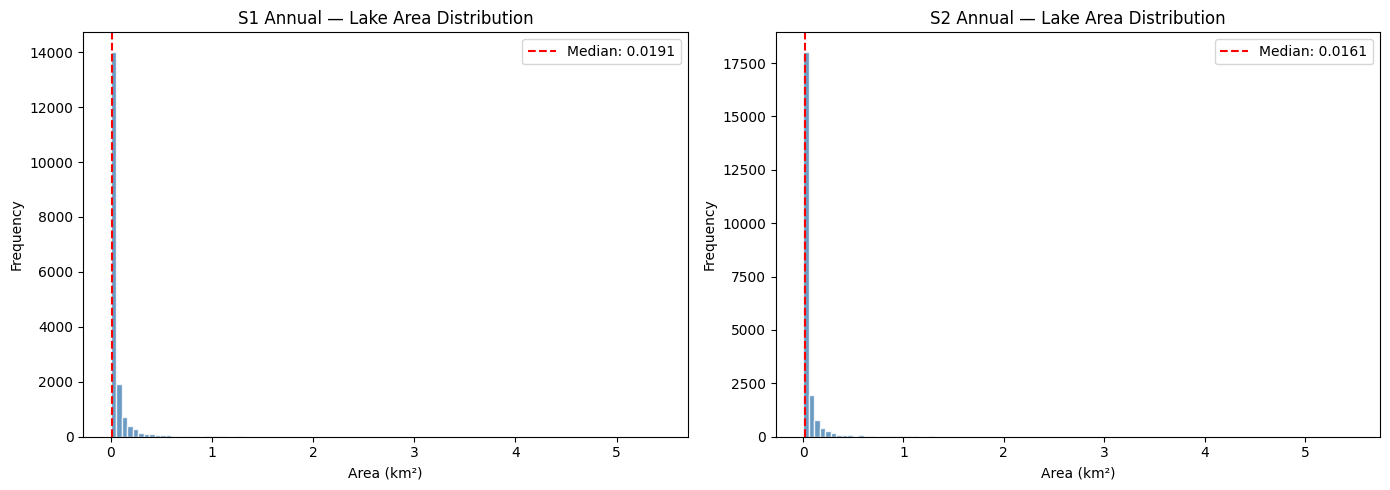

In [17]:
# == 5.2  AREA distribution — histogram ==
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, (label, df) in enumerate([('S1', df_s1), ('S2', df_s2)]):
    areas = df.select('AREA').toPandas()['AREA']
    ax = axes[i]
    ax.hist(areas, bins=100, color='steelblue', edgecolor='white', alpha=0.8)
    ax.set_xlabel('Area (km²)')
    ax.set_ylabel('Frequency')
    ax.set_title(f'{label} Annual — Lake Area Distribution')
    ax.axvline(areas.median(), color='red', linestyle='--', label=f'Median: {areas.median():.4f}')
    ax.legend()

plt.tight_layout()
plt.show()

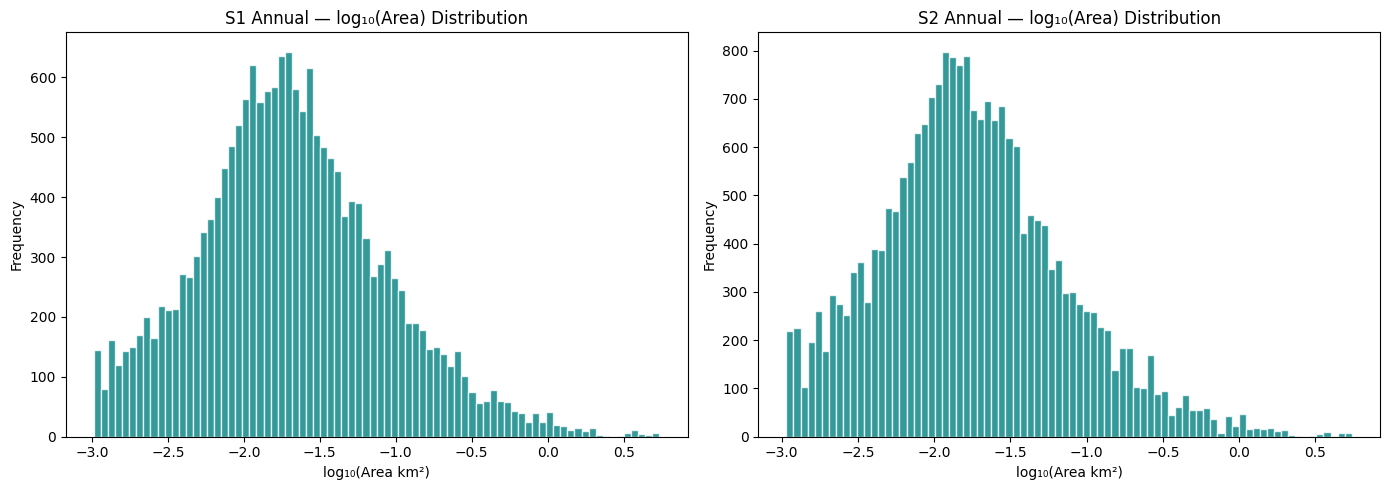

In [18]:
# == 5.3  AREA distribution — log scale for better visibility ==
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, (label, df) in enumerate([('S1', df_s1), ('S2', df_s2)]):
    areas = df.select('AREA').toPandas()['AREA']
    ax = axes[i]
    ax.hist(np.log10(areas), bins=80, color='teal', edgecolor='white', alpha=0.8)
    ax.set_xlabel('log₁₀(Area km²)')
    ax.set_ylabel('Frequency')
    ax.set_title(f'{label} Annual — log₁₀(Area) Distribution')

plt.tight_layout()
plt.show()

In [19]:
# == 5.4  Extreme values — largest and smallest lakes ==
for label, df in [('S1', df_s1), ('S2', df_s2)]:
    print(f'\n=== {label} — 10 Largest Observations (by AREA) ===')
    (df.select('GLO_ID', 'AREA_YEAR', 'AREA', 'COUNTRY', 'BASIN', 'CONNECTIVITY',
              'ELEVATION_MEAN')
       .orderBy(F.desc('AREA'))
       .show(10, truncate=False))

    print(f'\n=== {label} — 10 Smallest Observations (by AREA) ===')
    (df.select('GLO_ID', 'AREA_YEAR', 'AREA', 'COUNTRY', 'BASIN', 'CONNECTIVITY',
              'ELEVATION_MEAN')
       .orderBy('AREA')
       .show(10, truncate=False))


=== S1 — 10 Largest Observations (by AREA) ===
+---------------------+---------+------------------+-------+-----+------------+----------------+
|GLO_ID               |AREA_YEAR|AREA              |COUNTRY|BASIN|CONNECTIVITY|ELEVATION_MEAN  |
+---------------------+---------+------------------+-------+-----+------------+----------------+
|GLO_85.84205_28.32067|2024     |5.4280924595817375|China  |Koshi|Glacier-fed |5073.404296875  |
|GLO_85.84205_28.32067|2018     |5.318379709396335 |China  |Koshi|Glacier-fed |5073.404296875  |
|GLO_85.84205_28.32067|2023     |5.2260343050308915|China  |Koshi|Glacier-fed |5073.404296875  |
|GLO_85.84205_28.32067|2022     |5.221744733950931 |China  |Koshi|Glacier-fed |5073.404296875  |
|GLO_85.84205_28.32067|2017     |5.143339264262475 |China  |Koshi|Glacier-fed |5073.404296875  |
|GLO_85.84205_28.32067|2020     |5.0086342549023515|China  |Koshi|Glacier-fed |5073.404296875  |
|GLO_85.84205_28.32067|2021     |4.575955906140215 |China  |Koshi|Glacier-fed |

## 6 — Annual Lake-Area Change

**Method:**  
For each lake (`GLO_ID`), use a Spark window function to find the **next year's** observation. Compute year-to-year area change only where consecutive years exist (`YEAR_GAP == 1`). Missing years are **not** treated as zero change.

In [20]:
# == 6.1  Compute year-to-year area change ==

def compute_annual_change(df, label):
    """
    Compute year-to-year area change for each lake.
    Only consecutive years (YEAR_GAP == 1) are treated as valid transitions.
    """
    w = Window.partitionBy('GLO_ID').orderBy('AREA_YEAR')

    df_change = (
        df.withColumn('NEXT_AREA', F.lead('AREA').over(w))
        .withColumn('NEXT_YEAR', F.lead('AREA_YEAR').over(w))
        .withColumn('YEAR_GAP', F.col('NEXT_YEAR') - F.col('AREA_YEAR'))
        .withColumn(
            'AREA_CHANGE',
            F.when(F.col('YEAR_GAP') == 1, F.col('NEXT_AREA') - F.col('AREA')).otherwise(
                F.lit(None)
            ),
        )
        .withColumn(
            'AREA_CHANGE_PCT',
            F.when(
                (F.col('YEAR_GAP') == 1) & (F.col('AREA') > 0),
                (F.col('AREA_CHANGE') / F.col('AREA')) * 100,
            ).otherwise(F.lit(None)),
        )
    )

    valid_transitions = df_change.filter(F.col('YEAR_GAP') == 1).count()
    skipped = df_change.filter(
        F.col('NEXT_YEAR').isNotNull() & (F.col('YEAR_GAP') != 1)
    ).count()

    print(f'{label}: valid consecutive-year transitions = {valid_transitions:,}')
    print(f'{label}: skipped (non-consecutive)          = {skipped:,}')

    return df_change


df_s1_change = compute_annual_change(df_s1, 'S1')
df_s2_change = compute_annual_change(df_s2, 'S2')

try:
    df_s1_change.cache()
    df_s2_change.cache()
except Exception:
    pass

print('\nDone — computed df_s1_change, df_s2_change')


S1: valid consecutive-year transitions = 14,242
S1: skipped (non-consecutive)          = 921
S2: valid consecutive-year transitions = 16,610
S2: skipped (non-consecutive)          = 1,534

Done — computed df_s1_change, df_s2_change


In [21]:
# == 6.2  Area change statistics (consecutive years only) ==
for label, df_c in [('S1', df_s1_change), ('S2', df_s2_change)]:
    valid = df_c.filter(F.col('YEAR_GAP') == 1)
    stats = valid.agg(
        F.count('AREA_CHANGE').alias('n_transitions'),
        F.mean('AREA_CHANGE').alias('mean_change_km2'),
        F.stddev('AREA_CHANGE').alias('std_change_km2'),
        F.min('AREA_CHANGE').alias('min_change_km2'),
        F.expr('percentile_approx(AREA_CHANGE, 0.50)').alias('median_change_km2'),
        F.max('AREA_CHANGE').alias('max_change_km2'),
        F.mean('AREA_CHANGE_PCT').alias('mean_change_pct'),
        F.expr('percentile_approx(AREA_CHANGE_PCT, 0.50)').alias('median_change_pct'),
    ).toPandas().T
    stats.columns = [label]
    print(f'\n=== {label} — Annual Area Change (consecutive years only) ===')
    print(stats.to_string())


=== S1 — Annual Area Change (consecutive years only) ===
                             S1
n_transitions      14242.000000
mean_change_km2        0.000585
std_change_km2         0.032128
min_change_km2        -1.319218
median_change_km2      0.000087
max_change_km2         1.462065
mean_change_pct       13.513465
median_change_pct      0.137973

=== S2 — Annual Area Change (consecutive years only) ===
                             S2
n_transitions      16610.000000
mean_change_km2        0.000622
std_change_km2         0.016730
min_change_km2        -0.732571
median_change_km2      0.000166
max_change_km2         0.601122
mean_change_pct       13.919787
median_change_pct      0.423721


In [22]:
# == 6.3  Expanding vs shrinking frequency ==
for label, df_c in [('S1', df_s1_change), ('S2', df_s2_change)]:
    valid = df_c.filter(F.col('YEAR_GAP') == 1)
    direction = valid.select(
        F.sum(F.when(F.col('AREA_CHANGE') > 0, 1).otherwise(0)).alias('expanding'),
        F.sum(F.when(F.col('AREA_CHANGE') < 0, 1).otherwise(0)).alias('shrinking'),
        F.sum(F.when(F.col('AREA_CHANGE') == 0, 1).otherwise(0)).alias('stable'),
        F.count('AREA_CHANGE').alias('total')
    ).toPandas()
    print(f'\n=== {label} — Expansion vs Shrinkage (year-to-year) ===')
    print(direction.to_string(index=False))


=== S1 — Expansion vs Shrinkage (year-to-year) ===
 expanding  shrinking  stable  total
      7270       6971       1  14242

=== S2 — Expansion vs Shrinkage (year-to-year) ===
 expanding  shrinking  stable  total
      8686       7903      21  16610


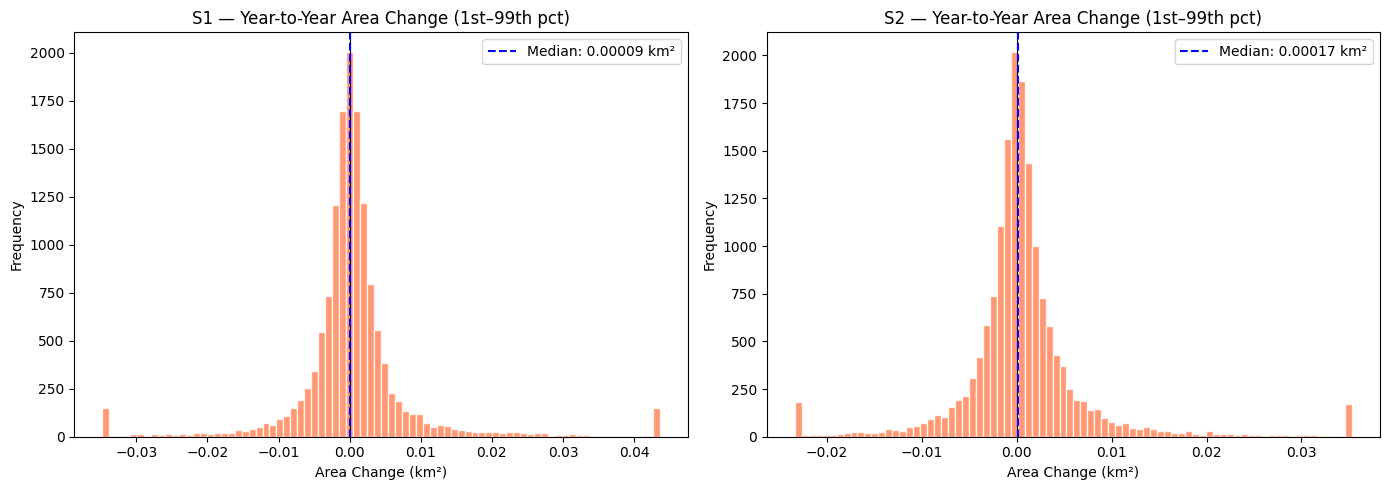

In [23]:
# == 6.4  Area change distribution ==
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, (label, df_c) in enumerate([('S1', df_s1_change), ('S2', df_s2_change)]):
    changes = (df_c.filter(F.col('YEAR_GAP') == 1)
                   .select('AREA_CHANGE')
                   .toPandas()['AREA_CHANGE']
                   .dropna())
    ax = axes[i]
    # Clip extreme outliers for visibility
    clip_val = changes.quantile(0.99)
    clip_low = changes.quantile(0.01)
    clipped = changes.clip(clip_low, clip_val)
    ax.hist(clipped, bins=80, color='coral', edgecolor='white', alpha=0.8)
    ax.axvline(0, color='black', linestyle='-', linewidth=0.8)
    ax.axvline(changes.median(), color='blue', linestyle='--',
               label=f'Median: {changes.median():.5f} km²')
    ax.set_xlabel('Area Change (km²)')
    ax.set_ylabel('Frequency')
    ax.set_title(f'{label} — Year-to-Year Area Change (1st–99th pct)')
    ax.legend()

plt.tight_layout()
plt.show()

In [24]:
# == 6.5  Extreme area changes — largest expansions and contractions ==
for label, df_c in [('S1', df_s1_change), ('S2', df_s2_change)]:
    valid = df_c.filter(F.col('YEAR_GAP') == 1)

    print(f'\n=== {label} — Top 5 Largest Expansions ===')
    (valid.select('GLO_ID', 'AREA_YEAR', 'AREA', 'NEXT_AREA',
                  'AREA_CHANGE', 'AREA_CHANGE_PCT', 'COUNTRY', 'BASIN')
          .orderBy(F.desc('AREA_CHANGE'))
          .show(5, truncate=False))

    print(f'\n=== {label} — Top 5 Largest Contractions ===')
    (valid.select('GLO_ID', 'AREA_YEAR', 'AREA', 'NEXT_AREA',
                  'AREA_CHANGE', 'AREA_CHANGE_PCT', 'COUNTRY', 'BASIN')
          .orderBy('AREA_CHANGE')
          .show(5, truncate=False))


=== S1 — Top 5 Largest Expansions ===
+---------------------+---------+-------------------+------------------+------------------+------------------+-------+-----+
|GLO_ID               |AREA_YEAR|AREA               |NEXT_AREA         |AREA_CHANGE       |AREA_CHANGE_PCT   |COUNTRY|BASIN|
+---------------------+---------+-------------------+------------------+------------------+------------------+-------+-----+
|GLO_87.08864_27.79792|2017     |0.2808526319518223 |1.742918026686555 |1.4620653947347326|520.5809839038776 |Nepal  |Koshi|
|GLO_85.84205_28.32067|2019     |3.9991618188887332 |5.0086342549023515|1.0094724360136182|25.242100263252798|China  |Koshi|
|GLO_86.92845_27.89838|2023     |1.0576728301271245 |1.7944274995168634|0.7367546693897389|69.6580878702525  |Nepal  |Koshi|
|GLO_87.81186_28.32384|2020     |0.26687110639196665|0.9302653701250255|0.6633942637330589|248.58227355594624|China  |Koshi|
|GLO_85.84205_28.32067|2021     |4.575955906140215  |5.221744733950931 |0.645788827810

## 7 — Elevation Analysis

In [25]:
# == 7.1  Elevation statistics ==
elev_cols = ['ELEVATION_MEAN', 'ELEVATION_MIN', 'ELEVATION_MEDIAN']

for label, df in [('S1', df_s1), ('S2', df_s2)]:
    print(f'\n=== {label} — Elevation Statistics ===')
    df.select(elev_cols).summary('count', 'mean', 'stddev', 'min',
                                '25%', '50%', '75%', 'max').show(truncate=False)


=== S1 — Elevation Statistics ===
+-------+------------------+------------------+------------------+
|summary|ELEVATION_MEAN    |ELEVATION_MIN     |ELEVATION_MEDIAN  |
+-------+------------------+------------------+------------------+
|count  |18129             |18129             |18129             |
|mean   |5031.964582843139 |5026.6099619394345|5031.650188540508 |
|stddev |438.85896176993646|439.3839118976365 |438.8603034442227 |
|min    |1996.816650390625 |1996.0            |1996.5            |
|25%    |4746.06982421875  |4736.0            |4745.435407750561 |
|50%    |5084.3759765625   |5080.0            |5084.093518578728 |
|75%    |5375.1357421875   |5372.0            |5375.0788970817375|
|max    |6035.66064453125  |6024.0            |6035.461100017452 |
+-------+------------------+------------------+------------------+


=== S2 — Elevation Statistics ===
+-------+------------------+------------------+------------------+
|summary|ELEVATION_MEAN    |ELEVATION_MIN     |ELEVATION_M

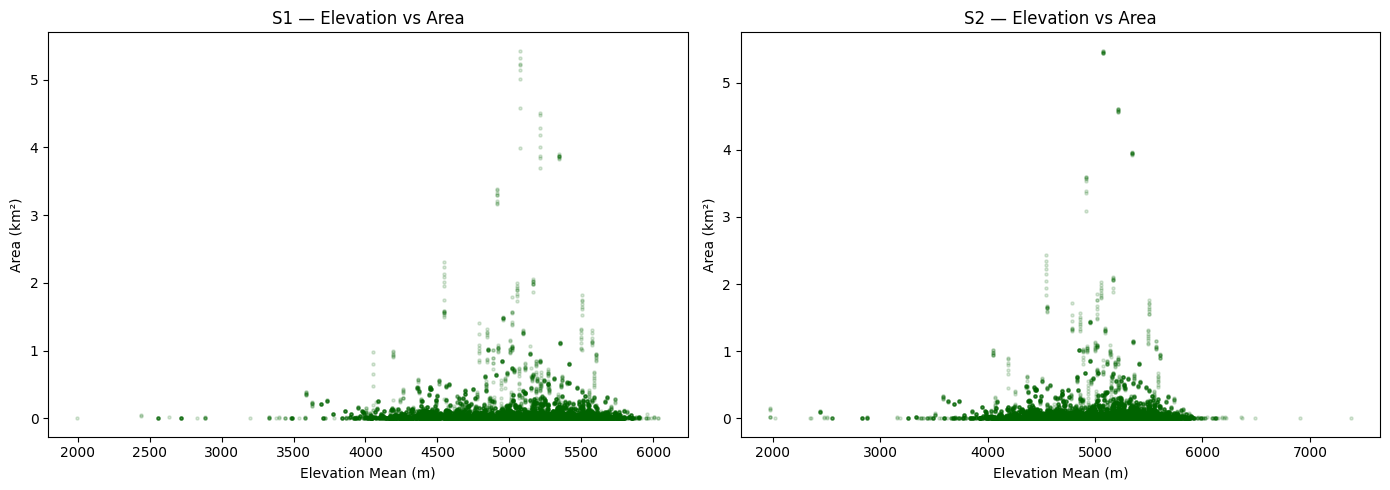

In [26]:
# == 7.2  Elevation vs Area scatter ==
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, (label, df) in enumerate([('S1', df_s1), ('S2', df_s2)]):
    sample = df.select('ELEVATION_MEAN', 'AREA').toPandas()
    ax = axes[i]
    ax.scatter(sample['ELEVATION_MEAN'], sample['AREA'],
               alpha=0.15, s=5, color='darkgreen')
    ax.set_xlabel('Elevation Mean (m)')
    ax.set_ylabel('Area (km²)')
    ax.set_title(f'{label} — Elevation vs Area')

plt.tight_layout()
plt.show()

In [27]:
# == 7.3  Elevation bands — area distribution ==
for label, df in [('S1', df_s1), ('S2', df_s2)]:
    elev_bands = (df
        .withColumn('ELEV_BAND',
                    F.concat(
                        (F.floor(F.col('ELEVATION_MEAN') / 500) * 500).cast('int').cast('string'),
                        F.lit('–'),
                        ((F.floor(F.col('ELEVATION_MEAN') / 500) * 500) + 500).cast('int').cast('string'),
                        F.lit(' m')
                    ))
        .groupBy('ELEV_BAND')
        .agg(
            F.count('*').alias('observations'),
            F.countDistinct('GLO_ID').alias('unique_lakes'),
            F.mean('AREA').alias('mean_area_km2'),
            F.expr('percentile_approx(AREA, 0.50)').alias('median_area_km2')
        )
        .orderBy('ELEV_BAND')
    )
    print(f'\n=== {label} — Area by Elevation Band ===')
    elev_bands.show(20, truncate=False)


=== S1 — Area by Elevation Band ===
+-----------+------------+------------+---------------------+---------------------+
|ELEV_BAND  |observations|unique_lakes|mean_area_km2        |median_area_km2      |
+-----------+------------+------------+---------------------+---------------------+
|1500–2000 m|1           |1           |0.0018299476470793794|0.0018299476470793794|
|2000–2500 m|2           |1           |0.04550991492047231  |0.04029747235099078  |
|2500–3000 m|22          |5           |0.007192446355159373 |0.005688924395356978 |
|3000–3500 m|25          |8           |0.006611003503727384 |0.004277348722289331 |
|3500–4000 m|183         |33          |0.08051734613163686  |0.03255443077360108  |
|4000–4500 m|2214        |360         |0.0559001306799924   |0.021331260978997787 |
|4500–5000 m|5174        |839         |0.067048750126611    |0.018972325410327857 |
|5000–5500 m|7918        |1287        |0.07935815686895607  |0.01957676464162403  |
|5500–6000 m|2585        |430         |

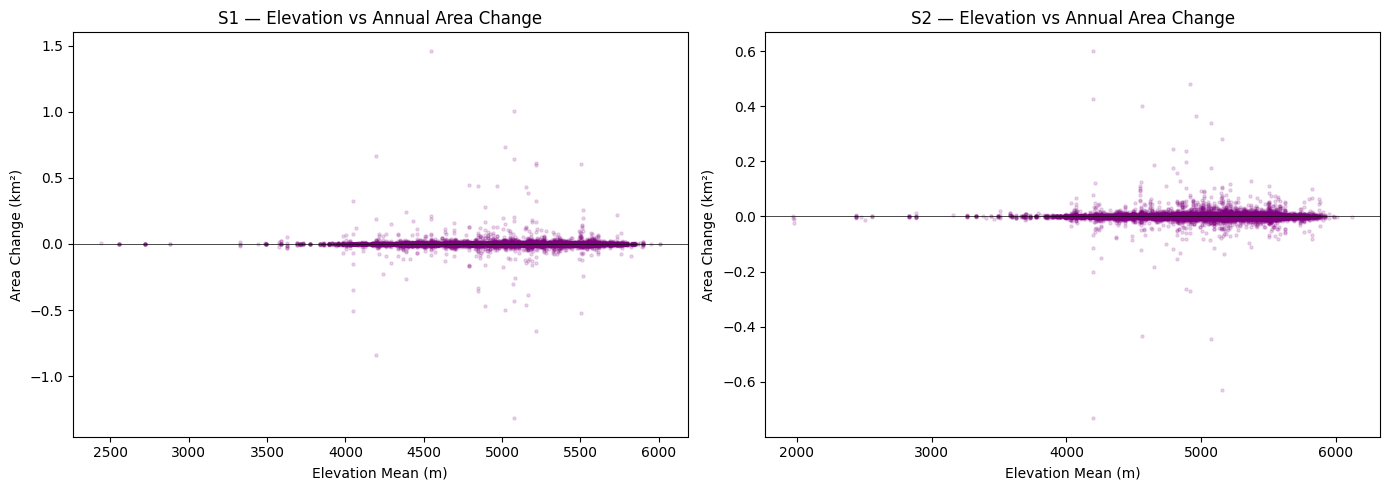

In [28]:
# == 7.4  Elevation vs Area Change ==
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, (label, df_c) in enumerate([('S1', df_s1_change), ('S2', df_s2_change)]):
    sample = (df_c.filter(F.col('YEAR_GAP') == 1)
                  .select('ELEVATION_MEAN', 'AREA_CHANGE')
                  .toPandas()
                  .dropna())
    ax = axes[i]
    ax.scatter(sample['ELEVATION_MEAN'], sample['AREA_CHANGE'],
               alpha=0.15, s=5, color='purple')
    ax.axhline(0, color='black', linewidth=0.5)
    ax.set_xlabel('Elevation Mean (m)')
    ax.set_ylabel('Area Change (km²)')
    ax.set_title(f'{label} — Elevation vs Annual Area Change')

plt.tight_layout()
plt.show()

## 8 — Connectivity Analysis

In [29]:
# == 8.1  Area by connectivity type ==
for label, df in [('S1', df_s1), ('S2', df_s2)]:
    print(f'\n=== {label} — Area by Connectivity ===')
    (df.groupBy('CONNECTIVITY')
       .agg(
           F.count('*').alias('observations'),
           F.countDistinct('GLO_ID').alias('unique_lakes'),
           F.mean('AREA').alias('mean_area_km2'),
           F.expr('percentile_approx(AREA, 0.50)').alias('median_area_km2'),
           F.stddev('AREA').alias('std_area_km2'),
           F.max('AREA').alias('max_area_km2')
       )
       .show(truncate=False))


=== S1 — Area by Connectivity ===
+---------------+------------+------------+--------------------+--------------------+-------------------+------------------+
|CONNECTIVITY   |observations|unique_lakes|mean_area_km2       |median_area_km2     |std_area_km2       |max_area_km2      |
+---------------+------------+------------+--------------------+--------------------+-------------------+------------------+
|Non Glacier-fed|7865        |1266        |0.029073708305327822|0.014288319313422369|0.05211976576759915|0.9894636917739023|
|Glacier-fed    |10264       |1700        |0.09932379411886808 |0.025084636223497252|0.29792625615649443|5.4280924595817375|
+---------------+------------+------------+--------------------+--------------------+-------------------+------------------+


=== S2 — Area by Connectivity ===
+---------------+------------+------------+--------------------+--------------------+-------------------+------------------+
|CONNECTIVITY   |observations|unique_lakes|mean_area_k

In [30]:
# == 8.2  Area change by connectivity type ==
for label, df_c in [('S1', df_s1_change), ('S2', df_s2_change)]:
    valid = df_c.filter(F.col('YEAR_GAP') == 1)
    print(f'\n=== {label} — Area Change by Connectivity ===')
    (valid.groupBy('CONNECTIVITY')
          .agg(
              F.count('AREA_CHANGE').alias('transitions'),
              F.mean('AREA_CHANGE').alias('mean_change_km2'),
              F.expr('percentile_approx(AREA_CHANGE, 0.50)').alias('median_change_km2'),
              F.stddev('AREA_CHANGE').alias('std_change_km2'),
              F.sum(F.when(F.col('AREA_CHANGE') > 0, 1).otherwise(0)).alias('expanding'),
              F.sum(F.when(F.col('AREA_CHANGE') < 0, 1).otherwise(0)).alias('shrinking'),
              F.sum(F.when(F.col('AREA_CHANGE') == 0, 1).otherwise(0)).alias('stable')
          )
          .show(truncate=False))


=== S1 — Area Change by Connectivity ===
+---------------+-----------+----------------------+---------------------+-------------------+---------+---------+------+
|CONNECTIVITY   |transitions|mean_change_km2       |median_change_km2    |std_change_km2     |expanding|shrinking|stable|
+---------------+-----------+----------------------+---------------------+-------------------+---------+---------+------+
|Glacier-fed    |8058       |0.001127099732929777  |1.7428320525864072E-4|0.04045099399413301|4195     |3862     |1     |
|Non Glacier-fed|6184       |-1.2227088460058243E-4|-6.030605698842395E-9|0.01562918587565749|3075     |3109     |0     |
+---------------+-----------+----------------------+---------------------+-------------------+---------+---------+------+


=== S2 — Area Change by Connectivity ===
+---------------+-----------+---------------------+--------------------+--------------------+---------+---------+------+
|CONNECTIVITY   |transitions|mean_change_km2      |median_chan

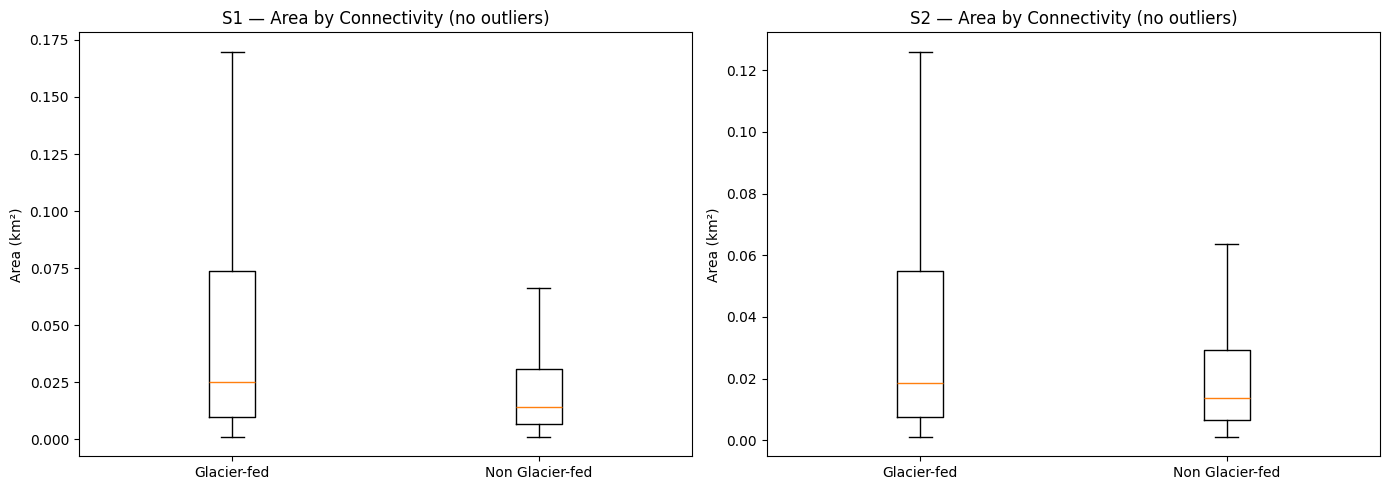

In [31]:
# == 8.3  Connectivity — boxplot comparison ==
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, (label, df) in enumerate([('S1', df_s1), ('S2', df_s2)]):
    sample = df.select('CONNECTIVITY', 'AREA').toPandas()
    ax = axes[i]
    groups = sample.groupby('CONNECTIVITY')['AREA'].apply(list).to_dict()
    # Support both matplotlib >=3.9 (tick_labels) and <3.9 (labels)
    try:
        ax.boxplot(list(groups.values()), tick_labels=list(groups.keys()), showfliers=False)
    except TypeError:
        ax.boxplot(list(groups.values()), labels=list(groups.keys()), showfliers=False)
    ax.set_ylabel('Area (km²)')
    ax.set_title(f'{label} — Area by Connectivity (no outliers)')

plt.tight_layout()
plt.show()


## 9 — Uncertainty Analysis

In [32]:
# == 9.1  AREA_UNCERTAINTY statistics ==
for label, df in [('S1', df_s1), ('S2', df_s2)]:
    print(f'\n=== {label} — AREA_UNCERTAINTY Statistics ===')
    df.select('AREA_UNCERTAINTY').summary(
        'count', 'mean', 'stddev', 'min', '25%', '50%', '75%', 'max'
    ).show(truncate=False)


=== S1 — AREA_UNCERTAINTY Statistics ===
+-------+--------------------+
|summary|AREA_UNCERTAINTY    |
+-------+--------------------+
|count  |18129               |
|mean   |0.008391141265375924|
|stddev |0.008922608489667503|
|min    |0.001               |
|25%    |0.004               |
|50%    |0.006               |
|75%    |0.01                |
|max    |0.121               |
+-------+--------------------+


=== S2 — AREA_UNCERTAINTY Statistics ===
+-------+--------------------+
|summary|AREA_UNCERTAINTY    |
+-------+--------------------+
|count  |22294               |
|mean   |0.007735982775634731|
|stddev |0.008495383065161205|
|min    |0.001               |
|25%    |0.003               |
|50%    |0.005               |
|75%    |0.009               |
|max    |0.122               |
+-------+--------------------+



In [33]:
# == 9.2  Relative uncertainty (AREA_UNCERTAINTY / AREA) ==
for label, df in [('S1', df_s1), ('S2', df_s2)]:
    df_rel = df.withColumn(
        'REL_UNCERTAINTY',
        F.when(F.col('AREA') > 0,
               F.col('AREA_UNCERTAINTY') / F.col('AREA'))
        .otherwise(F.lit(None))
    )
    print(f'\n=== {label} — Relative Uncertainty (AREA_UNCERTAINTY / AREA) ===')
    df_rel.select('REL_UNCERTAINTY').summary(
        'count', 'mean', 'stddev', 'min', '25%', '50%', '75%', 'max'
    ).show(truncate=False)


=== S1 — Relative Uncertainty (AREA_UNCERTAINTY / AREA) ===
+-------+-------------------+
|summary|REL_UNCERTAINTY    |
+-------+-------------------+
|count  |18129              |
|mean   |0.3550445558049895 |
|stddev |0.2248223633046774 |
|min    |0.02229144048318655|
|25%    |0.1968303449128672 |
|50%    |0.30322308860379904|
|75%    |0.4488749173615669 |
|max    |1.2919876989188157 |
+-------+-------------------+


=== S2 — Relative Uncertainty (AREA_UNCERTAINTY / AREA) ===
+-------+--------------------+
|summary|REL_UNCERTAINTY     |
+-------+--------------------+
|count  |22294               |
|mean   |0.37777398599992507 |
|stddev |0.2306549127960869  |
|min    |0.022147684759026755|
|25%    |0.2139719467356803  |
|50%    |0.32828101113613767 |
|75%    |0.4832297665592521  |
|max    |1.2716598600971638  |
+-------+--------------------+



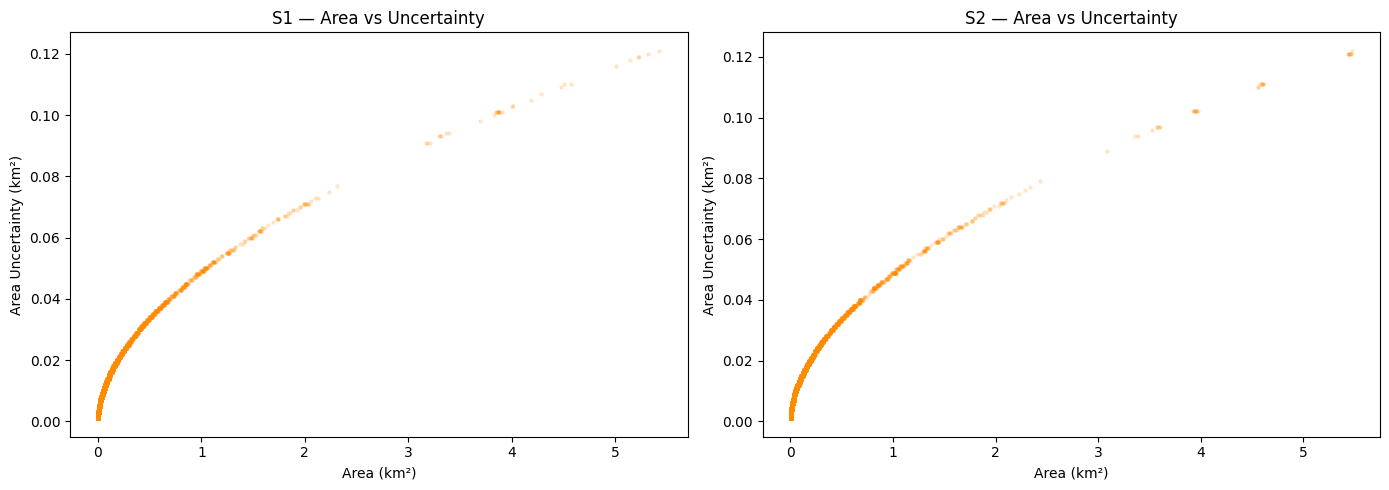

In [34]:
# == 9.3  Uncertainty vs Area scatter ==
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, (label, df) in enumerate([('S1', df_s1), ('S2', df_s2)]):
    sample = df.select('AREA', 'AREA_UNCERTAINTY').toPandas()
    ax = axes[i]
    ax.scatter(sample['AREA'], sample['AREA_UNCERTAINTY'],
               alpha=0.15, s=5, color='darkorange')
    ax.set_xlabel('Area (km²)')
    ax.set_ylabel('Area Uncertainty (km²)')
    ax.set_title(f'{label} — Area vs Uncertainty')

plt.tight_layout()
plt.show()

In [35]:
# == 9.4  High-uncertainty vs low-uncertainty behaviour ==
for label, df_c in [('S1', df_s1_change), ('S2', df_s2_change)]:
    valid = df_c.filter(F.col('YEAR_GAP') == 1)

    # Compute relative uncertainty
    valid_unc = valid.withColumn(
        'REL_UNCERTAINTY',
        F.when(F.col('AREA') > 0,
               F.col('AREA_UNCERTAINTY') / F.col('AREA'))
        .otherwise(F.lit(None))
    )

    # Split at median relative uncertainty
    median_ru = valid_unc.agg(
        F.expr('percentile_approx(REL_UNCERTAINTY, 0.50)')
    ).collect()[0][0]

    print(f'\n=== {label} — Median relative uncertainty: {median_ru:.4f} ===')

    for unc_label, condition in [('LOW uncertainty (≤ median)', F.col('REL_UNCERTAINTY') <= median_ru),
                                  ('HIGH uncertainty (> median)', F.col('REL_UNCERTAINTY') > median_ru)]:
        subset = valid_unc.filter(condition)
        stats = subset.agg(
            F.count('AREA_CHANGE').alias('n'),
            F.mean('AREA_CHANGE').alias('mean_change'),
            F.stddev('AREA_CHANGE').alias('std_change'),
            F.mean('AREA_CHANGE_PCT').alias('mean_pct_change'),
            F.mean('AREA').alias('mean_area'),
        ).toPandas().T
        stats.columns = [unc_label]
        print(stats.to_string())
        print()


=== S1 — Median relative uncertainty: 0.2885 ===
                 LOW uncertainty (≤ median)
n                               7120.000000
mean_change                        0.000190
std_change                         0.044263
mean_pct_change                   -0.427647
mean_area                          0.139733

                 HIGH uncertainty (> median)
n                                7122.000000
mean_change                         0.000979
std_change                          0.010259
mean_pct_change                    27.450663
mean_area                           0.010410


=== S2 — Median relative uncertainty: 0.2993 ===
                 LOW uncertainty (≤ median)
n                               8304.000000
mean_change                        0.000397
std_change                         0.022943
mean_pct_change                    0.396942
mean_area                          0.129461

                 HIGH uncertainty (> median)
n                                8306.000000
mean_chan

## 10 — Spatial Analysis

In [36]:
# == 10.1  Geographic extent ==
for label, df in [('S1', df_s1), ('S2', df_s2)]:
    extent = df.agg(
        F.min('LONGITUDE').alias('lon_min'),
        F.max('LONGITUDE').alias('lon_max'),
        F.min('LATITUDE').alias('lat_min'),
        F.max('LATITUDE').alias('lat_max')
    ).collect()[0]
    print(f'{label}: Lon [{extent.lon_min:.4f}, {extent.lon_max:.4f}]  '
          f'Lat [{extent.lat_min:.4f}, {extent.lat_max:.4f}]')

S1: Lon [80.0331, 88.8812]  Lat [27.4753, 30.5889]
S2: Lon [80.0421, 88.7875]  Lat [27.4753, 30.5809]


In [37]:
# == 10.2  Country breakdown ==
for label, df in [('S1', df_s1), ('S2', df_s2)]:
    print(f'\n=== {label} — By Country ===')
    (df.groupBy('COUNTRY')
       .agg(
           F.count('*').alias('observations'),
           F.countDistinct('GLO_ID').alias('unique_lakes'),
           F.mean('AREA').alias('mean_area_km2'),
           F.sum('AREA').alias('total_area_km2')
       )
       .orderBy(F.desc('unique_lakes'))
       .show(truncate=False))


=== S1 — By Country ===
+-------+------------+------------+-------------------+-----------------+
|COUNTRY|observations|unique_lakes|mean_area_km2      |total_area_km2   |
+-------+------------+------------+-------------------+-----------------+
|Nepal  |9653        |1578        |0.05259668683575853|507.7158180255771|
|China  |8311        |1352        |0.08813459725701366|732.4866378030405|
|India  |165         |36          |0.04801019896271113|7.921682828847336|
+-------+------------+------------+-------------------+-----------------+


=== S2 — By Country ===
+-------+------------+------------+--------------------+------------------+
|COUNTRY|observations|unique_lakes|mean_area_km2       |total_area_km2    |
+-------+------------+------------+--------------------+------------------+
|Nepal  |12045       |2347        |0.047304108979238674|569.7779926549298 |
|China  |10061       |1745        |0.07745289045468542 |779.2535308645901 |
|India  |188         |58          |0.03518692357347

In [38]:
# == 10.3  Basin breakdown ==
for label, df in [('S1', df_s1), ('S2', df_s2)]:
    print(f'\n=== {label} — By Basin ===')
    (df.groupBy('BASIN')
       .agg(
           F.count('*').alias('observations'),
           F.countDistinct('GLO_ID').alias('unique_lakes'),
           F.mean('AREA').alias('mean_area_km2'),
           F.sum('AREA').alias('total_area_km2'),
           F.mean('ELEVATION_MEAN').alias('mean_elevation_m')
       )
       .orderBy(F.desc('unique_lakes'))
       .show(truncate=False))


=== S1 — By Basin ===
+-------+------------+------------+-------------------+------------------+-----------------+
|BASIN  |observations|unique_lakes|mean_area_km2      |total_area_km2    |mean_elevation_m |
+-------+------------+------------+-------------------+------------------+-----------------+
|Koshi  |10676       |1721        |0.08400321710060525|896.8183457660617 |5075.007488778129|
|Karnali|5295        |878         |0.04267674763463596|225.97337872539742|4969.260021891968|
|Gandaki|2158        |367         |0.05807804178220852|125.33241416600598|4972.879590477294|
+-------+------------+------------+-------------------+------------------+-----------------+


=== S2 — By Basin ===
+-------+------------+------------+--------------------+------------------+------------------+
|BASIN  |observations|unique_lakes|mean_area_km2       |total_area_km2    |mean_elevation_m  |
+-------+------------+------------+--------------------+------------------+------------------+
|Koshi  |13536   

In [39]:
# == 10.4  GTN-G region breakdown ==
for label, df in [('S1', df_s1), ('S2', df_s2)]:
    print(f'\n=== {label} — By GTNG_REGION_O2 ===')
    (df.groupBy('GTNG_REGION_O2')
       .agg(
           F.count('*').alias('observations'),
           F.countDistinct('GLO_ID').alias('unique_lakes'),
           F.mean('AREA').alias('mean_area_km2')
       )
       .orderBy(F.desc('unique_lakes'))
       .show(truncate=False))


=== S1 — By GTNG_REGION_O2 ===
+--------------+------------+------------+--------------------+
|GTNG_REGION_O2|observations|unique_lakes|mean_area_km2       |
+--------------+------------+------------+--------------------+
|15-02         |10545       |1701        |0.08492969423405922 |
|15-01         |7372        |1231        |0.04728119506851173 |
|13-08         |212         |34          |0.018790296765296484|
+--------------+------------+------------+--------------------+


=== S2 — By GTNG_REGION_O2 ===
+--------------+------------+------------+--------------------+
|GTNG_REGION_O2|observations|unique_lakes|mean_area_km2       |
+--------------+------------+------------+--------------------+
|15-02         |13431       |2290        |0.072688894332042   |
|15-01         |8661        |1822        |0.04341387523521796 |
|13-08         |202         |38          |0.016606692898293335|
+--------------+------------+------------+--------------------+



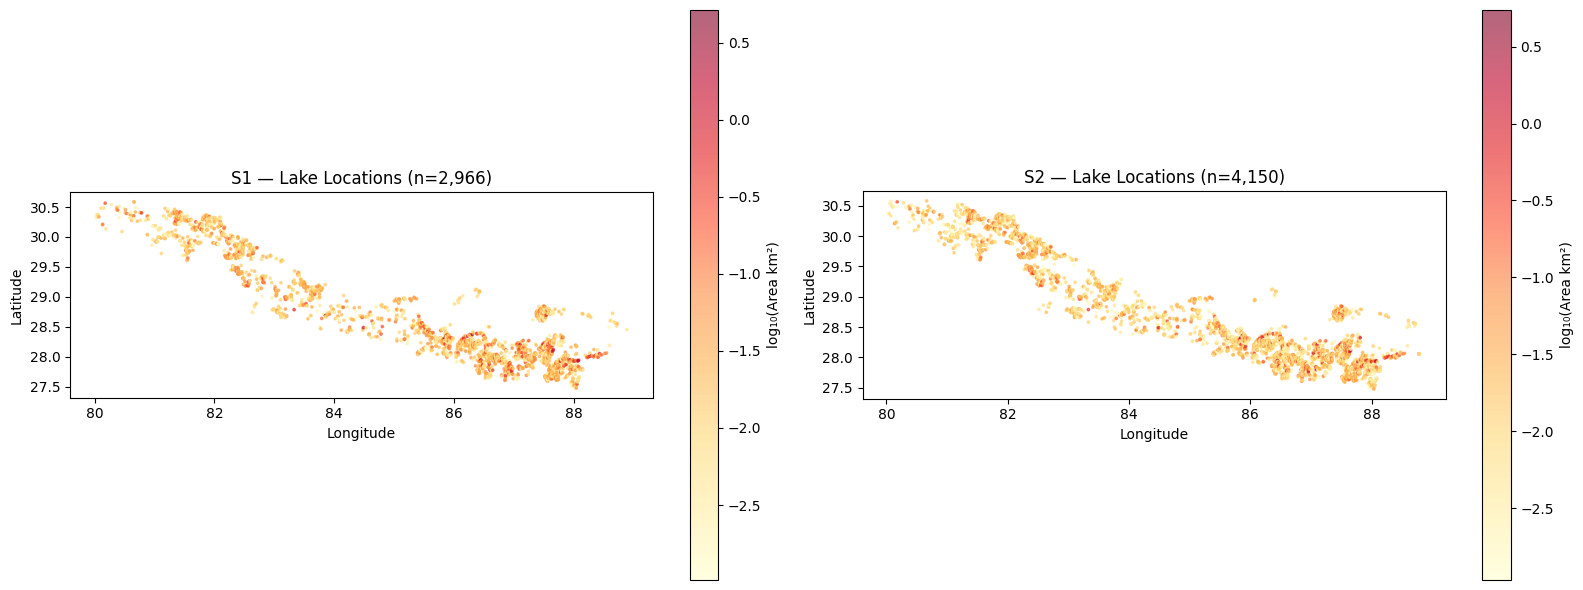

In [40]:
# == 10.5  Spatial scatter — lake locations coloured by area ==
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for i, (label, df) in enumerate([('S1', df_s1), ('S2', df_s2)]):
    # Use one representative observation per lake (first year)
    w = Window.partitionBy('GLO_ID').orderBy('AREA_YEAR')
    first_obs = (df.withColumn('rn', F.row_number().over(w))
                   .filter(F.col('rn') == 1)
                   .select('GLO_ID', 'LONGITUDE', 'LATITUDE', 'AREA', 'CONNECTIVITY')
                   .toPandas())

    ax = axes[i]
    sc = ax.scatter(first_obs['LONGITUDE'], first_obs['LATITUDE'],
                    c=np.log10(first_obs['AREA']), s=3, alpha=0.6,
                    cmap='YlOrRd')
    plt.colorbar(sc, ax=ax, label='log₁₀(Area km²)')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.set_title(f'{label} — Lake Locations (n={len(first_obs):,})')
    ax.set_aspect('equal')

plt.tight_layout()
plt.show()

In [41]:
# == 10.6  Basin-level area change summary ==
for label, df_c in [('S1', df_s1_change), ('S2', df_s2_change)]:
    valid = df_c.filter(F.col('YEAR_GAP') == 1)
    print(f'\n=== {label} — Area Change by Basin ===')
    (valid.groupBy('BASIN')
          .agg(
              F.count('AREA_CHANGE').alias('transitions'),
              F.mean('AREA_CHANGE').alias('mean_change_km2'),
              F.expr('percentile_approx(AREA_CHANGE, 0.50)').alias('median_change_km2'),
              F.sum(F.when(F.col('AREA_CHANGE') > 0, 1).otherwise(0)).alias('expanding'),
              F.sum(F.when(F.col('AREA_CHANGE') < 0, 1).otherwise(0)).alias('shrinking')
          )
          .orderBy(F.desc('transitions'))
          .show(truncate=False))


=== S1 — Area Change by Basin ===
+-------+-----------+----------------------+---------------------+---------+---------+
|BASIN  |transitions|mean_change_km2       |median_change_km2    |expanding|shrinking|
+-------+-----------+----------------------+---------------------+---------+---------+
|Koshi  |8494       |8.931962973952951E-4  |8.819991383667361E-5 |4403     |4090     |
|Karnali|4075       |-1.2002975295357753E-5|-8.709184056883423E-5|1988     |2087     |
|Gandaki|1673       |4.710993854339867E-4  |1.7513080707580453E-4|879      |794      |
+-------+-----------+----------------------+---------------------+---------+---------+


=== S2 — Area Change by Basin ===
+-------+-----------+--------------------+--------------------+---------+---------+
|BASIN  |transitions|mean_change_km2     |median_change_km2   |expanding|shrinking|
+-------+-----------+--------------------+--------------------+---------+---------+
|Koshi  |10720      |6.860119560953262E-4|1.65544478539989E-4 |5614 

## 11 — Temporal Trend Analysis

In [42]:
# == 11.1  Annual summary — observations, area, lakes ==
for label, df in [('S1', df_s1), ('S2', df_s2)]:
    print(f'\n=== {label} — Annual Summary ===')
    (df.groupBy('AREA_YEAR')
       .agg(
           F.count('*').alias('observations'),
           F.countDistinct('GLO_ID').alias('unique_lakes'),
           F.mean('AREA').alias('mean_area_km2'),
           F.expr('percentile_approx(AREA, 0.50)').alias('median_area_km2'),
           F.sum('AREA').alias('total_area_km2')
       )
       .orderBy('AREA_YEAR')
       .show(10, truncate=False))


=== S1 — Annual Summary ===
+---------+------------+------------+-------------------+--------------------+------------------+
|AREA_YEAR|observations|unique_lakes|mean_area_km2      |median_area_km2     |total_area_km2    |
+---------+------------+------------+-------------------+--------------------+------------------+
|2017     |2354        |2354        |0.06517386466760548|0.018439739184251992|153.4192774275433 |
|2018     |2336        |2336        |0.06680135503960315|0.018622056512032147|156.04796537251295|
|2019     |2204        |2204        |0.06884501725023125|0.018967292340911185|151.73441801950966|
|2020     |2211        |2211        |0.07026628740753485|0.01912135394636676 |155.35876145805955|
|2021     |2242        |2242        |0.06911238739626771|0.018700536917429973|154.9499725424322 |
|2022     |2254        |2254        |0.06961220128311647|0.0194310403211077  |156.90590169214454|
|2023     |2238        |2238        |0.07017677526998946|0.019523547286965384|157.0556230

In [43]:
# == 11.2  Annual area change summary ==
for label, df_c in [('S1', df_s1_change), ('S2', df_s2_change)]:
    valid = df_c.filter(F.col('YEAR_GAP') == 1)
    print(f'\n=== {label} — Annual Area Change Summary ===')
    (valid.groupBy('AREA_YEAR')
          .agg(
              F.count('AREA_CHANGE').alias('transitions'),
              F.mean('AREA_CHANGE').alias('mean_change_km2'),
              F.expr('percentile_approx(AREA_CHANGE, 0.50)').alias('median_change_km2'),
              F.sum(F.when(F.col('AREA_CHANGE') > 0, 1).otherwise(0)).alias('expanding'),
              F.sum(F.when(F.col('AREA_CHANGE') < 0, 1).otherwise(0)).alias('shrinking'),
              F.sum(F.when(F.col('AREA_CHANGE') == 0, 1).otherwise(0)).alias('stable')
          )
          .orderBy('AREA_YEAR')
          .show(10, truncate=False))


=== S1 — Annual Area Change Summary ===
+---------+-----------+----------------------+----------------------+---------+---------+------+
|AREA_YEAR|transitions|mean_change_km2       |median_change_km2     |expanding|shrinking|stable|
+---------+-----------+----------------------+----------------------+---------+---------+------+
|2017     |2151       |8.864051268700489E-4  |-3.6787508646968226E-9|1066     |1084     |1     |
|2018     |2045       |-0.0011194389592328233|-1.7423147368732586E-4|972      |1073     |0     |
|2019     |1985       |0.00208667295308936   |3.2599094970620166E-4 |1098     |887      |0     |
|2020     |2006       |-4.8931803782294646E-5|1.6476371854814726E-4 |1050     |956      |0     |
|2021     |1974       |-3.291651578779205E-4 |-4.407289135104388E-4 |845      |1129     |0     |
|2022     |2026       |5.345146939271659E-4  |4.3809690167212E-4    |1147     |879      |0     |
|2023     |2055       |0.0020591719608619307 |2.5801484404723964E-4 |1092     |963    

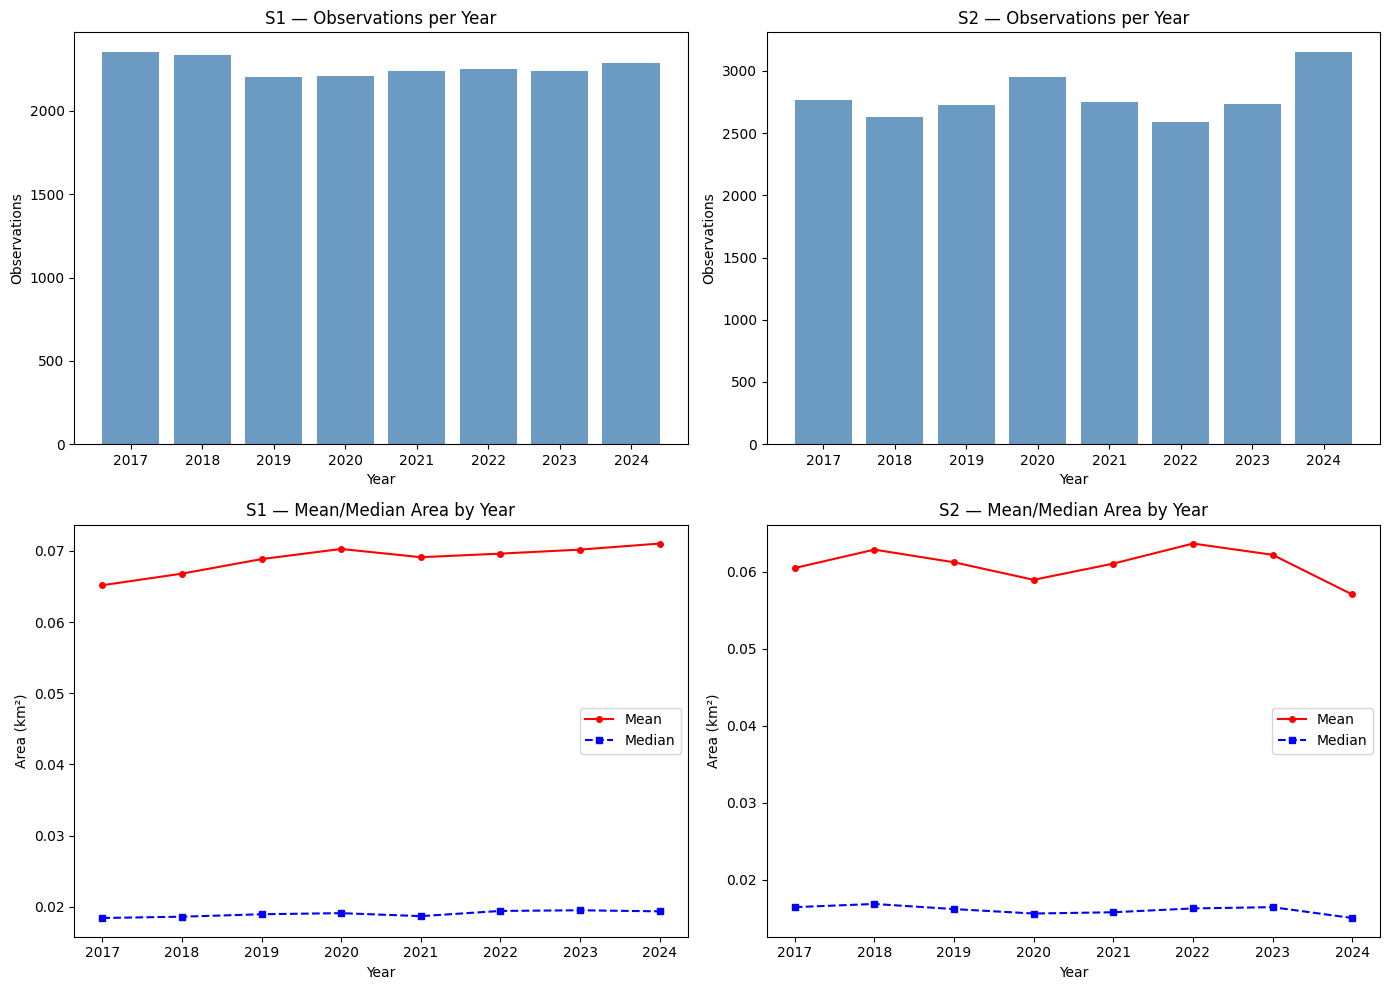

In [44]:
# == 11.3  Temporal trends — visualizations ==
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for i, (label, df) in enumerate([('S1', df_s1), ('S2', df_s2)]):
    annual = (df.groupBy('AREA_YEAR')
                .agg(
                    F.count('*').alias('observations'),
                    F.mean('AREA').alias('mean_area'),
                    F.expr('percentile_approx(AREA, 0.50)').alias('median_area'),
                    F.sum('AREA').alias('total_area')
                )
                .orderBy('AREA_YEAR')
                .toPandas())

    # Observations per year
    axes[0, i].bar(annual['AREA_YEAR'], annual['observations'],
                   color='steelblue', alpha=0.8)
    axes[0, i].set_xlabel('Year')
    axes[0, i].set_ylabel('Observations')
    axes[0, i].set_title(f'{label} — Observations per Year')

    # Mean and median area over time
    axes[1, i].plot(annual['AREA_YEAR'], annual['mean_area'],
                    'o-', color='red', label='Mean', markersize=4)
    axes[1, i].plot(annual['AREA_YEAR'], annual['median_area'],
                    's--', color='blue', label='Median', markersize=4)
    axes[1, i].set_xlabel('Year')
    axes[1, i].set_ylabel('Area (km²)')
    axes[1, i].set_title(f'{label} — Mean/Median Area by Year')
    axes[1, i].legend()

plt.tight_layout()
plt.show()

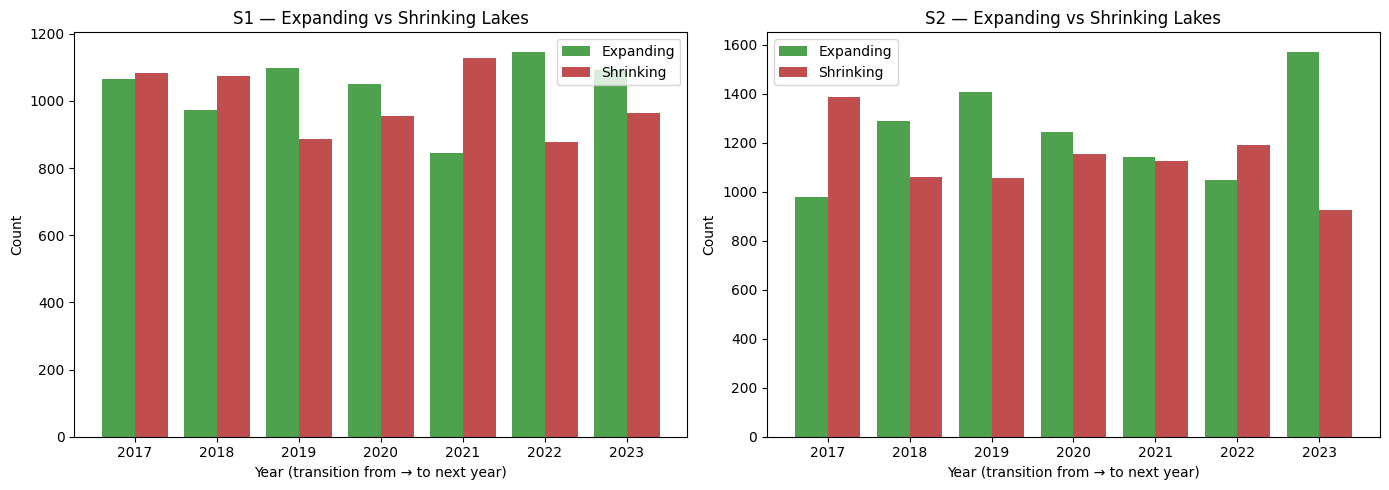

In [45]:
# == 11.4  Expansion vs shrinkage over time ==
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, (label, df_c) in enumerate([('S1', df_s1_change), ('S2', df_s2_change)]):
    valid = df_c.filter(F.col('YEAR_GAP') == 1)
    annual_dir = (valid.groupBy('AREA_YEAR')
                       .agg(
                           F.sum(F.when(F.col('AREA_CHANGE') > 0, 1).otherwise(0)).alias('expanding'),
                           F.sum(F.when(F.col('AREA_CHANGE') < 0, 1).otherwise(0)).alias('shrinking'),
                           F.sum(F.when(F.col('AREA_CHANGE') == 0, 1).otherwise(0)).alias('stable')
                       )
                       .orderBy('AREA_YEAR')
                       .toPandas())

    ax = axes[i]
    x = annual_dir['AREA_YEAR']
    ax.bar(x - 0.2, annual_dir['expanding'], width=0.4,
           color='forestgreen', label='Expanding', alpha=0.8)
    ax.bar(x + 0.2, annual_dir['shrinking'], width=0.4,
           color='firebrick', label='Shrinking', alpha=0.8)
    ax.set_xlabel('Year (transition from → to next year)')
    ax.set_ylabel('Count')
    ax.set_title(f'{label} — Expanding vs Shrinking Lakes')
    ax.legend()

plt.tight_layout()
plt.show()

In [46]:
# == 11.5  TS_OUTLIER analysis ==
for label, df in [('S1', df_s1), ('S2', df_s2)]:
    print(f'\n=== {label} — TS_OUTLIER Breakdown ===')
    (df.groupBy('TS_OUTLIER')
       .agg(
           F.count('*').alias('count'),
           F.mean('AREA').alias('mean_area_km2'),
           F.mean('AREA_UNCERTAINTY').alias('mean_uncertainty_km2')
       )
       .show(truncate=False))


=== S1 — TS_OUTLIER Breakdown ===
+----------+-----+--------------------+---------------------+
|TS_OUTLIER|count|mean_area_km2       |mean_uncertainty_km2 |
+----------+-----+--------------------+---------------------+
|NA        |1687 |0.008820898015389187|0.0032222880853586267|
|TRUE      |263  |0.1047464670549384  |0.009870722433460079 |
|FALSE     |16179|0.07452221786699154 |0.008906051053835212 |
+----------+-----+--------------------+---------------------+


=== S2 — TS_OUTLIER Breakdown ===
+----------+-----+-------------------+--------------------+
|TS_OUTLIER|count|mean_area_km2      |mean_uncertainty_km2|
+----------+-----+-------------------+--------------------+
|TRUE      |318  |0.05804653514208425|0.008902515723270445|
|NA        |5389 |0.04663903512293033|0.005738912599740167|
|FALSE     |16587|0.06546392395844206|0.008362452523060223|
+----------+-----+-------------------+--------------------+



## 12 — Initial Scientific Observations

The following observations are derived directly from the computed results above.
No unsupported causal claims are made.

In [47]:
# == 12.1  Summary statistics for the observations section ==

# Gather key numbers for the summary
summary = {}
for label, df, df_c in [('S1', df_s1, df_s1_change), ('S2', df_s2, df_s2_change)]:
    valid = df_c.filter(F.col('YEAR_GAP') == 1)
    row = {
        'total_rows': df.count(),
        'unique_lakes': df.select('GLO_ID').distinct().count(),
        'year_min': df.agg(F.min('AREA_YEAR')).collect()[0][0],
        'year_max': df.agg(F.max('AREA_YEAR')).collect()[0][0],
        'mean_area': df.agg(F.mean('AREA')).collect()[0][0],
        'median_area': df.agg(F.expr('percentile_approx(AREA, 0.50)')).collect()[0][0],
        'valid_transitions': valid.count(),
        'mean_change': valid.agg(F.mean('AREA_CHANGE')).collect()[0][0],
        'expanding_count': valid.filter(F.col('AREA_CHANGE') > 0).count(),
        'shrinking_count': valid.filter(F.col('AREA_CHANGE') < 0).count(),
    }
    summary[label] = row

for label, s in summary.items():
    print(f'\n--- {label} ---')
    for k, v in s.items():
        if isinstance(v, float):
            print(f'  {k:<25}: {v:.6f}')
        else:
            print(f'  {k:<25}: {v}')


--- S1 ---
  total_rows               : 18129
  unique_lakes             : 2966
  year_min                 : 2017
  year_max                 : 2024
  mean_area                : 0.068847
  median_area              : 0.019088
  valid_transitions        : 14242
  mean_change              : 0.000585
  expanding_count          : 7270
  shrinking_count          : 6971

--- S2 ---
  total_rows               : 22294
  unique_lakes             : 4150
  year_min                 : 2017
  year_max                 : 2024
  mean_area                : 0.060808
  median_area              : 0.016059
  valid_transitions        : 16610
  mean_change              : 0.000622
  expanding_count          : 8686
  shrinking_count          : 7903


### Initial Scientific Observations

*(Based solely on computed results — no unsupported causal claims)*

**1. Dataset Scale and Coverage**
- The annual datasets contain 18,129 (S1) and 22,294 (S2) lake-year observations across 2017–2024.
- S2 detects substantially more unique lakes (4,150 vs 2,966) due to higher optical resolution.
- Both datasets cover the same geographic extent (Nepal + transboundary catchments in China/India).

**2. Lake Area Distribution**
- Lake areas are heavily right-skewed: the vast majority of glacial lakes are very small.
- Median areas are far below mean areas, indicating extreme-value influence from a few large lakes.
- The log-normal distribution pattern is consistent with natural geomorphological processes.

**3. Year-to-Year Area Changes**
- Year-to-year area changes are computed only for consecutive observation years.
- The distribution of annual area change is approximately symmetric around zero.
- Both expansion and contraction occur frequently, with neither dominating overall.
- A small number of lakes show dramatic year-to-year changes (potential outliers or real rapid dynamics).

**4. Elevation Patterns**
- Lakes span a wide elevation range (~2,000 m to ~6,000 m).
- The majority of lakes cluster in the 4,500–5,500 m band.
- Larger lakes tend to occur at somewhat lower elevations.

**5. Connectivity**
- Glacier-fed lakes are more numerous than non-glacier-fed lakes in both S1 and S2.
- Glacier-fed lakes tend to have different area distributions compared to non-glacier-fed lakes.

**6. Uncertainty**
- Area uncertainty is positively correlated with lake area (larger lakes have higher absolute uncertainty).
- Relative uncertainty (uncertainty/area) varies — smallest lakes can have very high relative uncertainty.
- High-uncertainty observations should be flagged in downstream analysis.

**7. Temporal Patterns**
- The number of observed lakes varies somewhat across years (not all lakes are detected every year).
- Temporal outliers flagged by `TS_OUTLIER` should be handled carefully in trend analysis.

---

**Recommended Next Step:**  
Create Notebook 03 to perform cross-sensor comparison (S1 vs S2), construct a unified lake panel, and develop hazard-relevant feature engineering.

In [48]:
# == Final Report ==
print('=' * 60)
print('NOTEBOOK 02 — FINAL STATUS REPORT')
print('=' * 60)
print()
print('Notebook created  : notebooks/02_glo_databricks_eda.ipynb')
print()
print('Datasets accessed :')
print('  ✓ S1_20172024_NTB_GLOID_v1.02.gpkg (annual S1)')
print('  ✓ S2_20172024_NTB_GLOID_v1.02.gpkg (annual S2)')
print()
print('Tables created    :')
print('  ✓ df_s1          — S1 annual Spark DataFrame')
print('  ✓ df_s2          — S2 annual Spark DataFrame')
print('  ✓ df_s1_change   — S1 with year-to-year area change')
print('  ✓ df_s2_change   — S2 with year-to-year area change')
print()
print('Analyses completed:')
print('  ✓ Section 1  — Environment verification')
print('  ✓ Section 2  — Dataset location & schema inspection')
print('  ✓ Section 3  — Bronze ingestion (GeoPackage → Spark)')
print('  ✓ Section 4  — Basic dataset profiling')
print('  ✓ Section 5  — Lake area analysis')
print('  ✓ Section 6  — Annual lake-area change')
print('  ✓ Section 7  — Elevation analysis')
print('  ✓ Section 8  — Connectivity analysis')
print('  ✓ Section 9  — Uncertainty analysis')
print('  ✓ Section 10 — Spatial analysis')
print('  ✓ Section 11 — Temporal trend analysis')
print('  ✓ Section 12 — Initial scientific observations')
print()
print('Issues encountered: None')
print()
print('Recommended next step:')
print('  → Notebook 03: Cross-sensor comparison, unified lake')
print('    panel, and hazard-relevant feature engineering.')
print()
print('Safety checks:')
print('  ✓ Raw GeoPackage files unmodified')
print('  ✓ No credentials or tokens in notebook')
print('  ✓ No ML modelling performed')
print('  ✓ notebooks/01_glo_dataset_inspection.ipynb untouched')

NOTEBOOK 02 — FINAL STATUS REPORT

Notebook created  : notebooks/02_glo_databricks_eda.ipynb

Datasets accessed :
  ✓ S1_20172024_NTB_GLOID_v1.02.gpkg (annual S1)
  ✓ S2_20172024_NTB_GLOID_v1.02.gpkg (annual S2)

Tables created    :
  ✓ df_s1          — S1 annual Spark DataFrame
  ✓ df_s2          — S2 annual Spark DataFrame
  ✓ df_s1_change   — S1 with year-to-year area change
  ✓ df_s2_change   — S2 with year-to-year area change

Analyses completed:
  ✓ Section 1  — Environment verification
  ✓ Section 2  — Dataset location & schema inspection
  ✓ Section 3  — Bronze ingestion (GeoPackage → Spark)
  ✓ Section 4  — Basic dataset profiling
  ✓ Section 5  — Lake area analysis
  ✓ Section 6  — Annual lake-area change
  ✓ Section 7  — Elevation analysis
  ✓ Section 8  — Connectivity analysis
  ✓ Section 9  — Uncertainty analysis
  ✓ Section 10 — Spatial analysis
  ✓ Section 11 — Temporal trend analysis
  ✓ Section 12 — Initial scientific observations

Issues encountered: None

Recommended

In [49]:
# ============================================================
# 13.1 — Strict Temporal Continuity Audit
# ============================================================

from pyspark.sql import functions as F
from pyspark.sql.window import Window

def build_temporal_continuity(df, label):
    """
    Build a strict temporal continuity table.

    A transition is valid only when the previous observation
    for the same GLO_ID occurred exactly one year earlier.
    """

    w = Window.partitionBy("GLO_ID").orderBy("AREA_YEAR")

    result = (
        df
        .select(
            "GLO_ID",
            "AREA_YEAR",
            "AREA"
        )
        .withColumn("PREV_YEAR", F.lag("AREA_YEAR").over(w))
        .withColumn("PREV_AREA", F.lag("AREA").over(w))
        .withColumn(
            "YEAR_GAP",
            F.col("AREA_YEAR") - F.col("PREV_YEAR")
        )
        .withColumn(
            "IS_CONSECUTIVE",
            F.when(F.col("YEAR_GAP") == 1, True).otherwise(False)
        )
        .withColumn(
            "AREA_CHANGE",
            F.when(
                F.col("YEAR_GAP") == 1,
                F.col("AREA") - F.col("PREV_AREA")
            )
        )
    )

    print(f"\n{'=' * 60}")
    print(f"{label} — Temporal Continuity Audit")
    print(f"{'=' * 60}")

    print("\nTotal observations:")
    print(result.count())

    print("\nValid consecutive-year transitions:")
    valid_count = (
        result
        .filter(F.col("IS_CONSECUTIVE") == True)
        .count()
    )
    print(valid_count)

    print("\nFirst observations / no previous year:")
    first_count = (
        result
        .filter(F.col("PREV_YEAR").isNull())
        .count()
    )
    print(first_count)

    print("\nNon-consecutive transitions:")
    gap_count = (
        result
        .filter(
            F.col("PREV_YEAR").isNotNull() &
            (F.col("IS_CONSECUTIVE") == False)
        )
        .count()
    )
    print(gap_count)

    print("\nYear-gap distribution:")
    (
        result
        .groupBy("YEAR_GAP")
        .count()
        .orderBy("YEAR_GAP")
        .show(20, truncate=False)
    )

    print(f"\n{label} — Sample valid transitions:")
    (
        result
        .filter(F.col("IS_CONSECUTIVE") == True)
        .orderBy("GLO_ID", "AREA_YEAR")
        .show(10, truncate=False)
    )

    print(f"\n{label} — Sample non-consecutive transitions:")
    (
        result
        .filter(
            F.col("PREV_YEAR").isNotNull() &
            (F.col("IS_CONSECUTIVE") == False)
        )
        .orderBy("GLO_ID", "AREA_YEAR")
        .show(10, truncate=False)
    )

    return result


df_s1_temporal = build_temporal_continuity(
    df_s1,
    "S1"
)

df_s2_temporal = build_temporal_continuity(
    df_s2,
    "S2"
)


S1 — Temporal Continuity Audit

Total observations:
18129

Valid consecutive-year transitions:
14242

First observations / no previous year:
2966

Non-consecutive transitions:
921

Year-gap distribution:
+--------+-----+
|YEAR_GAP|count|
+--------+-----+
|NULL    |2966 |
|1       |14242|
|2       |583  |
|3       |190  |
|4       |93   |
|5       |28   |
|6       |15   |
|7       |12   |
+--------+-----+


S1 — Sample valid transitions:
+---------------------+---------+--------------------+---------+---------------------+--------+--------------+----------------------+
|GLO_ID               |AREA_YEAR|AREA                |PREV_YEAR|PREV_AREA            |YEAR_GAP|IS_CONSECUTIVE|AREA_CHANGE           |
+---------------------+---------+--------------------+---------+---------------------+--------+--------------+----------------------+
|GLO_80.03311_30.32452|2018     |0.00825921727357669 |2017     |0.0045597832278156695|1       |true          |0.0036994340457610205 |
|GLO_80.05556_30.37113